# Amropali Mango Leaf Disease Classification — Research Pipeline

**7 classes** : Anthracnose, Bacterial Canker, Healthy, Powdery Mildew, Scab, Sooty Mould, Stem End Rot (500 images each).

This notebook is written in a clear *student-researcher* style and is meant to run end-to-end on **Kaggle (GPU)**.

**Pipeline**
1. Dataset discovery + EDA
2. Data pre-processing + augmentation (saved to disk)
3. Baseline transfer-learning models — VGG16, InceptionV3, Xception, MobileNetV3, EfficientNet-B0
4. **Proposed lightweight hybrid** — `AA-ENet` : EfficientNet-B0 + CBAM attention + a small Transformer encoder (a true CNN–Transformer hybrid, ~5–6M params, *not* the heavy `MS-EfficientNet-B0 + CPE-DeiT-Tiny + CAFM + SupCon` design)
5. Optuna hyper-parameters (manual best params used to save time)
6. 5-Fold cross-validation
7. Ablation study
8. Statistical tests (McNemar + paired t-test)
9. Benchmarking comparison table
10. Explainable AI — Grad-CAM, LIME, SHAP
11. Final results summary

> **Before running:** turn **Internet ON** (Settings ▸ Internet) so the pretrained backbones can download, and select a **GPU** accelerator.


## 0. Optional package installs
Most packages already exist on Kaggle. `lime` / `optuna` are installed quietly if missing.

In [1]:
# Keep dependencies small. Only install what Kaggle may be missing.
import importlib, subprocess, sys

def ensure(pkg, pip_name=None):
    try:
        importlib.import_module(pkg)
        print(f"[ok] {pkg}")
    except Exception:
        name = pip_name or pkg
        print(f"[install] {name} ...")
        subprocess.run([sys.executable, "-m", "pip", "-q", "install", name], check=False)

ensure("timm")
ensure("lime")
ensure("optuna")
ensure("shap")
print("Package check done.")

[ok] timm
[ok] lime
[ok] optuna
[ok] shap
Package check done.


## 1. Imports, seed and device

In [2]:
import os, gc, time, copy, random, warnings, json
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

import timm
from PIL import Image
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import (accuracy_score, precision_recall_fscore_support,
                             confusion_matrix, classification_report)
from scipy import stats

SEED = 42
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.benchmark = True  # faster, fine for this work

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Torch :", torch.__version__)
print("timm  :", timm.__version__)
print("Device:", DEVICE)
if DEVICE == "cuda":
    print("GPU   :", torch.cuda.get_device_name(0))

Torch : 2.10.0+cu128
timm  : 1.0.25
Device: cuda
GPU   : Tesla T4


## 2. Configuration
Everything tunable lives here. Turn `FAST_MODE = True` for a quick smoke-test run; keep it `False` for the real experiments.

In [3]:
# ---- Manual best parameters (from a previous Optuna search) ----
# The full Optuna study is very slow, so we reuse the best parameters.
# Note: lambda_supcon is kept for the record but NOT used here, because the
# lightweight hybrid does not use a SupCon contrastive loss.
BEST_PARAMS = {
    "lr": 2.49e-04,
    "wd": 7.97e-05,
    "dropout": 0.276633,
    "lambda_supcon": 0.212043,
}
print("="*60)
print("USING MANUAL BEST PARAMETERS")
print("="*60)
for k, v in BEST_PARAMS.items():
    print(f"{k:18s}: {v}")
print("="*60)

# ---- Run configuration ----
FAST_MODE = False          # True -> tiny run to verify the pipeline quickly

IMG_SIZE   = 224
BATCH_SIZE = 32
NUM_WORKERS = 2
TEST_FRAC  = 0.15          # hold-out test
VAL_FRAC   = 0.15          # validation (from the remaining data)

EPOCHS_BASELINE  = 10
EPOCHS_PROPOSED  = 15
EPOCHS_CV        = 8
EPOCHS_ABLATION  = 8
PATIENCE         = 4

CV_FOLDS      = 5
RUN_OPTUNA    = False      # set True to run a small demo Optuna study
OPTUNA_TRIALS = 8
OPTUNA_EPOCHS = 4

PRETRAINED      = True     # needs Internet ON
MAX_PER_CLASS   = None     # e.g. 120 for a faster experiment; None = use all

if FAST_MODE:
    EPOCHS_BASELINE = EPOCHS_PROPOSED = 2
    EPOCHS_CV = EPOCHS_ABLATION = 2
    CV_FOLDS = 3
    MAX_PER_CLASS = 60
    print(">>> FAST_MODE is ON (results are not final, only a smoke test)")

# ---- Output folder (everything is saved here on Kaggle) ----
RESULTS_DIR = "/kaggle/working/results"
os.makedirs(RESULTS_DIR, exist_ok=True)
print("All figures / models / tables will be saved to:", RESULTS_DIR)

# global stores filled while running
RESULTS   = {}   # model_name -> metrics dict
TEST_PRED = {}   # model_name -> predicted labels on the test set (for stats)

USING MANUAL BEST PARAMETERS
lr                : 0.000249
wd                : 7.97e-05
dropout           : 0.276633
lambda_supcon     : 0.212043
All figures / models / tables will be saved to: /kaggle/working/results


## 3. Dataset discovery and EDA

In [6]:
CLASS_HINTS = ["Anthracnose", "Bacterial Canker", "Healthy",
               "Powdery Mildew", "Scab", "Sooty Mould", "Stem End Rot"]

# Set DATA_DIR manually if auto-detection fails.
DATA_DIR = None

def looks_like_dataset(path):
    try:
        subs = [d for d in os.listdir(path)
                if os.path.isdir(os.path.join(path, d))]
    except Exception:
        return False
    hit = sum(any(h.lower() == s.lower() or h.lower() in s.lower()
                  for h in CLASS_HINTS) for s in subs)
    return hit >= 4

def find_data_dir(root="/kaggle/input"):
    if not os.path.isdir(root):
        return None
    for cur, dirs, _ in os.walk(root):
        if looks_like_dataset(cur):
            return cur
    return None

if DATA_DIR is None:
    DATA_DIR = find_data_dir()

assert DATA_DIR is not None, (
    "Dataset not found under /kaggle/input. "
    "Add the mango dataset to the notebook and/or set DATA_DIR manually.")

CLASSES = sorted([d for d in os.listdir(DATA_DIR)
                  if os.path.isdir(os.path.join(DATA_DIR, d))])
NUM_CLASSES = len(CLASSES)
CLASS_TO_IDX = {c: i for i, c in enumerate(CLASSES)}
print("Data directory :", DATA_DIR)
print("Classes        :", CLASSES)
print("Num classes    :", NUM_CLASSES)

Data directory : /kaggle/input/datasets/prantikbaroi/amrapali/Amrapali Mango Diseases Dataset
Classes        : ['Anthracnose', 'Bacterial Canker', 'Healthy', 'Powdery Mildew', 'Scab', 'Sooty Mould', 'Stem End Rot']
Num classes    : 7


class
Anthracnose         500
Bacterial Canker    500
Healthy             500
Powdery Mildew      500
Scab                500
Sooty Mould         500
Stem End Rot        500
Name: count, dtype: int64
Total images: 3500


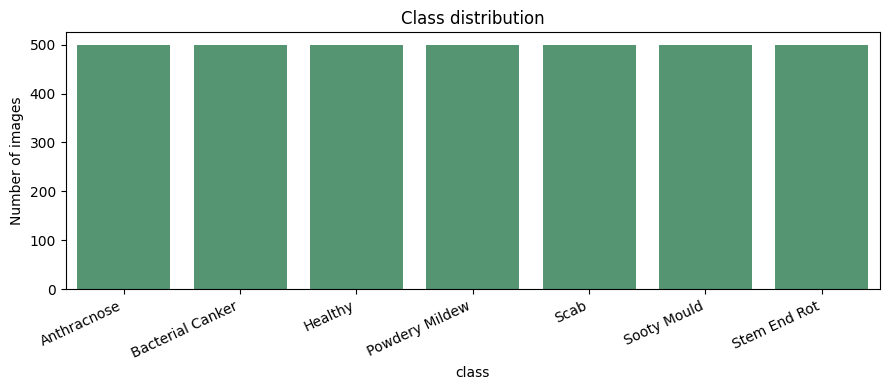

In [7]:
# Build the full file list and a class-distribution table
IMG_EXT = (".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff", ".webp")
rows = []
for c in CLASSES:
    cdir = os.path.join(DATA_DIR, c)
    files = [f for f in os.listdir(cdir) if f.lower().endswith(IMG_EXT)]
    files = sorted(files)
    if MAX_PER_CLASS is not None:
        files = files[:MAX_PER_CLASS]
    for f in files:
        rows.append({"path": os.path.join(cdir, f),
                     "class": c, "label": CLASS_TO_IDX[c]})

df = pd.DataFrame(rows).sample(frac=1.0, random_state=SEED).reset_index(drop=True)
dist = df["class"].value_counts().reindex(CLASSES)
print(dist)
print("Total images:", len(df))

plt.figure(figsize=(9, 4))
sns.barplot(x=dist.index, y=dist.values, color="#4C9F70")
plt.title("Class distribution"); plt.ylabel("Number of images")
plt.xticks(rotation=25, ha="right"); plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/class_distribution.png", dpi=130)
plt.show()

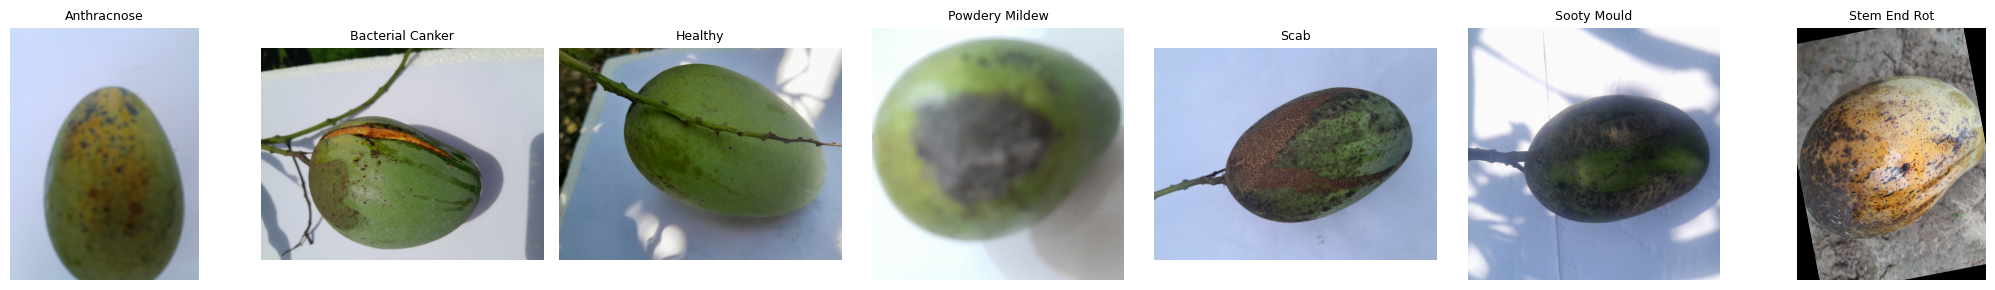

In [11]:
# Show one sample image per class
fig, axes = plt.subplots(1, NUM_CLASSES, figsize=(3*NUM_CLASSES, 3))
for ax, c in zip(np.atleast_1d(axes), CLASSES):
    p = df[df["class"] == c]["path"].iloc[0]
    ax.imshow(Image.open(p).convert("RGB"))
    ax.set_title(c, fontsize=9); ax.axis("off")
plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/sample_per_class.png", dpi=130)
plt.show()

## 4. Pre-processing and augmentation

**Pre-processing:** resize to 224×224 and normalise with ImageNet statistics (required by the pretrained backbones).

**Augmentation rationale (chosen for mango leaf disease):**
- *Horizontal & vertical flips* — a leaf has no fixed orientation, so flips are label-preserving.
- *Small rotation / affine* — handles slightly tilted captures.
- *Mild RandomResizedCrop* — focuses on different lesion regions and adds scale variety.
- *Gentle ColorJitter* — robustness to lighting; kept **subtle** because colour/spots are diagnostic and strong jitter would erase disease cues.

Heavy distortions (large colour shifts, cutout over lesions, strong blur) are deliberately avoided to prevent destroying the very features the model must learn.

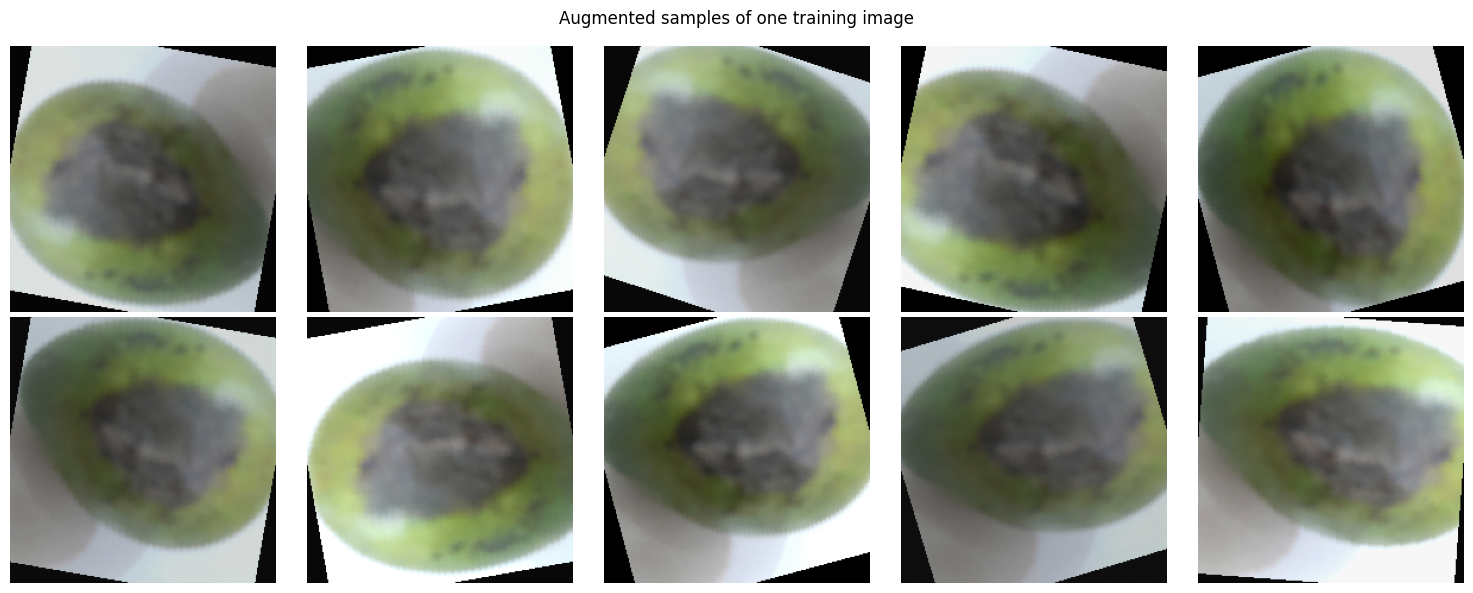

Augmentation grid saved.


In [12]:
from torchvision import transforms

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

train_tf = transforms.Compose([
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.75, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(20),
    transforms.ColorJitter(brightness=0.15, contrast=0.15, saturation=0.10),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

eval_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

def denorm(t):
    m = torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
    s = torch.tensor(IMAGENET_STD).view(3, 1, 1)
    return (t * s + m).clamp(0, 1)

# Save a grid of augmented versions of one image
sample_img = Image.open(df["path"].iloc[0]).convert("RGB")
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
for ax in axes.ravel():
    ax.imshow(denorm(train_tf(sample_img)).permute(1, 2, 0).numpy())
    ax.axis("off")
plt.suptitle("Augmented samples of one training image")
plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/augmentation_examples.png", dpi=130)
plt.show()
print("Augmentation grid saved.")

## 5. Dataset, stratified split and data loaders

In [13]:
class LeafDataset(Dataset):
    def __init__(self, frame, tf):
        self.frame = frame.reset_index(drop=True)
        self.tf = tf
    def __len__(self):
        return len(self.frame)
    def __getitem__(self, i):
        r = self.frame.iloc[i]
        img = Image.open(r["path"]).convert("RGB")
        return self.tf(img), int(r["label"])

# Stratified train / val / test split
train_val_df, test_df = train_test_split(
    df, test_size=TEST_FRAC, stratify=df["label"], random_state=SEED)
train_df, val_df = train_test_split(
    train_val_df, test_size=VAL_FRAC/(1-TEST_FRAC),
    stratify=train_val_df["label"], random_state=SEED)

print(f"Train: {len(train_df)}  Val: {len(val_df)}  Test: {len(test_df)}")

def make_loaders(tr_df, va_df, te_df, train_aug=True):
    tr = DataLoader(LeafDataset(tr_df, train_tf if train_aug else eval_tf),
                    batch_size=BATCH_SIZE, shuffle=True,
                    num_workers=NUM_WORKERS, pin_memory=True, drop_last=True)
    va = DataLoader(LeafDataset(va_df, eval_tf), batch_size=BATCH_SIZE,
                    shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)
    te = DataLoader(LeafDataset(te_df, eval_tf), batch_size=BATCH_SIZE,
                    shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)
    return tr, va, te

train_loader, val_loader, test_loader = make_loaders(train_df, val_df, test_df)

Train: 2450  Val: 525  Test: 525


## 6. Model definitions

**Baselines** are standard pretrained backbones with a new classification head.

**Proposed hybrid — `AA-ENet` (Attention-Augmented EfficientNet):**
1. EfficientNet-B0 backbone (pretrained) → feature map.
2. `1×1` conv reduces channels (1280 → 192) to stay lightweight.
3. **CBAM** (channel + spatial attention) re-weights lesion-relevant features.
4. A **single Transformer encoder layer** over the spatial tokens (CNN→Transformer hybrid) with a learnable CLS token captures global context.
5. The CLS token is fused with the global-average-pooled feature, followed by dropout and a linear classifier.

It is a genuine CNN–Transformer + attention hybrid, ~5–6M parameters, and is intentionally **not** the heavy `MS-EfficientNet-B0 + CPE-DeiT-Tiny + CAFM + SupCon` design.

In [14]:
def safe_create_model(candidates, **kw):
    last = None
    for name in candidates:
        try:
            m = timm.create_model(name, **kw)
            print(f"[model] using '{name}'")
            return m
        except Exception as e:
            last = e
    raise RuntimeError(f"Could not create any of {candidates}: {last}")

BASELINES = {
    "VGG16":          ["vgg16"],
    "InceptionV3":    ["inception_v3"],
    "Xception":       ["xception", "legacy_xception", "xception41"],
    "MobileNetV3":    ["mobilenetv3_large_100"],
    "EfficientNet_B0":["efficientnet_b0"],
}

def build_baseline(name):
    try:
        return safe_create_model(BASELINES[name], pretrained=PRETRAINED,
                                  num_classes=NUM_CLASSES)
    except Exception as e:
        print(f"[warn] pretrained download failed ({e}); using random init.")
        return safe_create_model(BASELINES[name], pretrained=False,
                                  num_classes=NUM_CLASSES)


class CBAM(nn.Module):
    # Convolutional Block Attention Module (channel + spatial attention)
    def __init__(self, ch, r=8):
        super().__init__()
        self.mlp = nn.Sequential(
            nn.Linear(ch, ch // r), nn.ReLU(inplace=True),
            nn.Linear(ch // r, ch))
        self.conv = nn.Conv2d(2, 1, 7, padding=3, bias=False)

    def forward(self, x):
        b, c, _, _ = x.shape
        avg = F.adaptive_avg_pool2d(x, 1).view(b, c)
        mx  = F.adaptive_max_pool2d(x, 1).view(b, c)
        ca  = torch.sigmoid(self.mlp(avg) + self.mlp(mx)).view(b, c, 1, 1)
        x   = x * ca
        sa  = torch.cat([x.mean(1, keepdim=True),
                         x.max(1, keepdim=True)[0]], dim=1)
        sa  = torch.sigmoid(self.conv(sa))
        return x * sa


class AAENet(nn.Module):
    # Proposed lightweight hybrid: EfficientNet-B0 + CBAM + 1 Transformer layer
    def __init__(self, num_classes, dropout=0.3, embed=192,
                 use_cbam=True, use_transformer=True):
        super().__init__()
        try:
            self.backbone = timm.create_model(
                "efficientnet_b0", pretrained=PRETRAINED,
                num_classes=0, global_pool="")
        except Exception:
            self.backbone = timm.create_model(
                "efficientnet_b0", pretrained=False,
                num_classes=0, global_pool="")
        feat_ch = self.backbone.num_features  # 1280

        self.reduce = nn.Sequential(
            nn.Conv2d(feat_ch, embed, 1, bias=False),
            nn.BatchNorm2d(embed), nn.ReLU(inplace=True))

        self.use_cbam = use_cbam
        self.cbam = CBAM(embed) if use_cbam else nn.Identity()

        self.use_transformer = use_transformer
        if use_transformer:
            self.cls = nn.Parameter(torch.zeros(1, 1, embed))
            self.pos = nn.Parameter(torch.zeros(1, 50, embed))  # 49 tokens + cls
            enc = nn.TransformerEncoderLayer(
                d_model=embed, nhead=4, dim_feedforward=embed*2,
                dropout=dropout, batch_first=True, activation="gelu")
            self.transformer = nn.TransformerEncoder(enc, num_layers=1)

        fuse_dim = embed * 2 if use_transformer else embed
        self.drop = nn.Dropout(dropout)
        self.head = nn.Linear(fuse_dim, num_classes)

    def forward(self, x):
        x = self.backbone(x)              # [B, 1280, 7, 7]
        x = self.reduce(x)                # [B, embed, 7, 7]
        x = self.cbam(x)
        gap = F.adaptive_avg_pool2d(x, 1).flatten(1)   # [B, embed]
        if self.use_transformer:
            b = x.size(0)
            tok = x.flatten(2).transpose(1, 2)         # [B, 49, embed]
            cls = self.cls.expand(b, -1, -1)
            tok = torch.cat([cls, tok], dim=1) + self.pos[:, :tok.size(1)+1]
            tok = self.transformer(tok)
            feat = torch.cat([gap, tok[:, 0]], dim=1)
        else:
            feat = gap
        return self.head(self.drop(feat))


def count_params(m):
    return sum(p.numel() for p in m.parameters()) / 1e6  # millions

_demo = AAENet(NUM_CLASSES, dropout=BEST_PARAMS["dropout"])
print(f"Proposed AA-ENet parameters: {count_params(_demo):.2f} M")
del _demo; gc.collect()

model.safetensors:   0%|          | 0.00/21.4M [00:00<?, ?B/s]

Proposed AA-ENet parameters: 4.57 M


61960

## 7. Training and evaluation utilities

In [19]:
def train_model(model, tr_loader, va_loader, epochs, lr, wd,
                 tag, patience=PATIENCE, verbose=True):
    model = model.to(DEVICE)
    crit  = nn.CrossEntropyLoss(label_smoothing=0.1)
    opt   = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=wd)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs)
    scaler = torch.cuda.amp.GradScaler(enabled=(DEVICE == "cuda"))

    hist = {"tr_loss": [], "va_loss": [], "tr_acc": [], "va_acc": []}
    best_loss, best_state, wait = float("inf"), None, 0

    for ep in range(epochs):
        # ---- train ----
        model.train(); tl = tc = n = 0
        for xb, yb in tr_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            opt.zero_grad()
            with torch.cuda.amp.autocast(enabled=(DEVICE == "cuda")):
                out = model(xb); loss = crit(out, yb)
            scaler.scale(loss).backward()
            scaler.step(opt); scaler.update()
            tl += loss.item()*xb.size(0)
            tc += (out.argmax(1) == yb).sum().item(); n += xb.size(0)
        tr_loss, tr_acc = tl/n, tc/n

        # ---- validate ----
        model.eval(); vl = vc = m = 0
        with torch.no_grad():
            for xb, yb in va_loader:
                xb, yb = xb.to(DEVICE), yb.to(DEVICE)
                out = model(xb); loss = crit(out, yb)
                vl += loss.item()*xb.size(0)
                vc += (out.argmax(1) == yb).sum().item(); m += xb.size(0)
        va_loss, va_acc = vl/m, vc/m
        sched.step()

        hist["tr_loss"].append(tr_loss); hist["va_loss"].append(va_loss)
        hist["tr_acc"].append(tr_acc);   hist["va_acc"].append(va_acc)
        if verbose:
            print(f"[{tag}] ep {ep+1:02d}/{epochs} "
                  f"tr_loss {tr_loss:.3f} tr_acc {tr_acc:.3f} | "
                  f"va_loss {va_loss:.3f} va_acc {va_acc:.3f}")

        if va_loss < best_loss - 1e-4:
            best_loss, best_state, wait = va_loss, copy.deepcopy(model.state_dict()), 0
        else:
            wait += 1
            if wait >= patience:
                if verbose: print(f"[{tag}] early stop at epoch {ep+1}")
                break

    if best_state is not None:
        model.load_state_dict(best_state)
    return model, hist


@torch.no_grad()
def evaluate(model, loader):
    model.eval(); ys, ps, pr = [], [], []
    for xb, yb in loader:
        xb = xb.to(DEVICE)
        out = model(xb)
        prob = F.softmax(out, dim=1).cpu().numpy()
        ps.extend(out.argmax(1).cpu().numpy())
        pr.extend(prob); ys.extend(yb.numpy())
    ys, ps = np.array(ys), np.array(ps)
    acc = accuracy_score(ys, ps)
    p, r, f1, _ = precision_recall_fscore_support(
        ys, ps, average="macro", zero_division=0)
    return {"acc": acc, "precision": p, "recall": r, "f1": f1,
            "y_true": ys, "y_pred": ps, "y_prob": np.array(pr)}


def plot_history(hist, name):
    fig, ax = plt.subplots(1, 2, figsize=(12, 4))
    ax[0].plot(hist["tr_loss"], label="train")
    ax[0].plot(hist["va_loss"], label="val")
    ax[0].set_title(f"{name} loss"); ax[0].legend(); ax[0].set_xlabel("epoch")
    ax[1].plot(hist["tr_acc"], label="train")
    ax[1].plot(hist["va_acc"], label="val")
    ax[1].set_title(f"{name} accuracy"); ax[1].legend(); ax[1].set_xlabel("epoch")
    plt.tight_layout()
    plt.savefig(f"{RESULTS_DIR}/{name}_curves.png", dpi=130)
    plt.show()


def plot_cm(y_true, y_pred, name):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Greens",
                xticklabels=CLASSES, yticklabels=CLASSES)
    plt.title(f"{name} — confusion matrix")
    plt.xlabel("Predicted"); plt.ylabel("True")
    plt.xticks(rotation=35, ha="right"); plt.yticks(rotation=0)
    plt.tight_layout()
    plt.savefig(f"{RESULTS_DIR}/{name}_confusion.png", dpi=130)
    plt.show()


def cleanup():
    gc.collect()
    if DEVICE == "cuda":
        torch.cuda.empty_cache()

## 8. Baseline models
Each baseline is trained, evaluated, plotted and saved to `/kaggle/working/results`.


TRAINING BASELINE: VGG16


model.safetensors:   0%|          | 0.00/553M [00:00<?, ?B/s]

[model] using 'vgg16'
[VGG16] ep 01/10 tr_loss 1.012 tr_acc 0.743 | va_loss 0.651 va_acc 0.926
[VGG16] ep 02/10 tr_loss 0.666 tr_acc 0.903 | va_loss 0.628 va_acc 0.910
[VGG16] ep 03/10 tr_loss 0.606 tr_acc 0.930 | va_loss 0.605 va_acc 0.933
[VGG16] ep 04/10 tr_loss 0.567 tr_acc 0.940 | va_loss 0.570 va_acc 0.933
[VGG16] ep 05/10 tr_loss 0.548 tr_acc 0.953 | va_loss 0.540 va_acc 0.962
[VGG16] ep 06/10 tr_loss 0.537 tr_acc 0.959 | va_loss 0.553 va_acc 0.943
[VGG16] ep 07/10 tr_loss 0.521 tr_acc 0.961 | va_loss 0.547 va_acc 0.952
[VGG16] ep 08/10 tr_loss 0.508 tr_acc 0.971 | va_loss 0.521 va_acc 0.960
[VGG16] ep 09/10 tr_loss 0.498 tr_acc 0.974 | va_loss 0.514 va_acc 0.970
[VGG16] ep 10/10 tr_loss 0.491 tr_acc 0.977 | va_loss 0.519 va_acc 0.966

VGG16: test_acc=0.9562  f1=0.9560  gap=0.0220


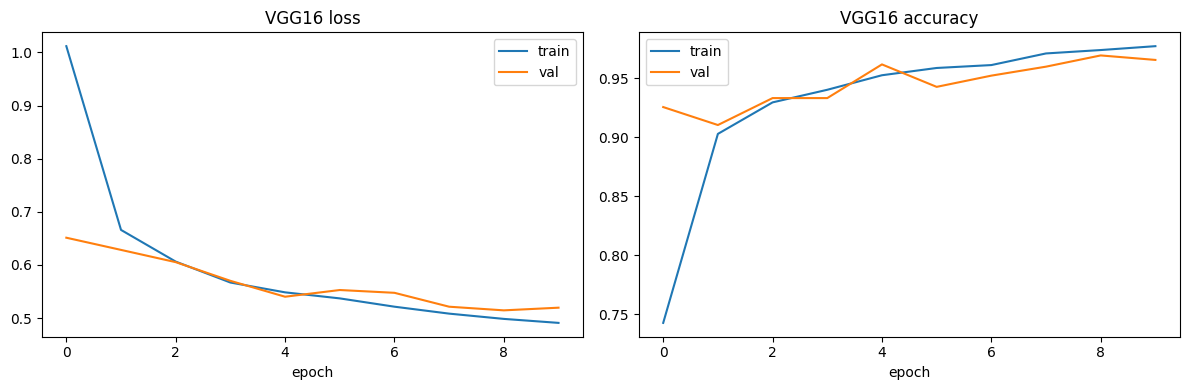

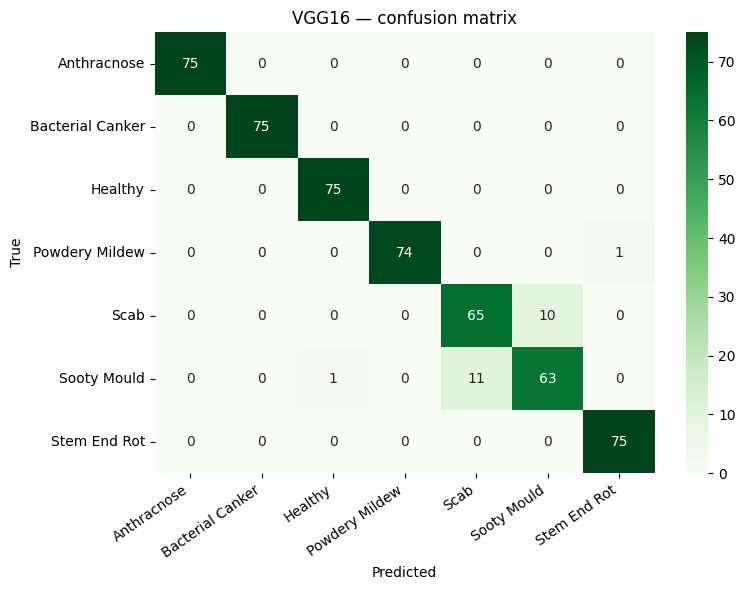

                  precision    recall  f1-score   support

     Anthracnose       1.00      1.00      1.00        75
Bacterial Canker       1.00      1.00      1.00        75
         Healthy       0.99      1.00      0.99        75
  Powdery Mildew       1.00      0.99      0.99        75
            Scab       0.86      0.87      0.86        75
     Sooty Mould       0.86      0.84      0.85        75
    Stem End Rot       0.99      1.00      0.99        75

        accuracy                           0.96       525
       macro avg       0.96      0.96      0.96       525
    weighted avg       0.96      0.96      0.96       525


TRAINING BASELINE: InceptionV3


model.safetensors:   0%|          | 0.00/95.5M [00:00<?, ?B/s]

[model] using 'inception_v3'
[InceptionV3] ep 01/10 tr_loss 0.926 tr_acc 0.849 | va_loss 0.646 va_acc 0.924
[InceptionV3] ep 02/10 tr_loss 0.616 tr_acc 0.943 | va_loss 0.588 va_acc 0.937
[InceptionV3] ep 03/10 tr_loss 0.567 tr_acc 0.958 | va_loss 0.562 va_acc 0.960
[InceptionV3] ep 04/10 tr_loss 0.558 tr_acc 0.961 | va_loss 0.542 va_acc 0.970
[InceptionV3] ep 05/10 tr_loss 0.529 tr_acc 0.975 | va_loss 0.536 va_acc 0.964
[InceptionV3] ep 06/10 tr_loss 0.519 tr_acc 0.978 | va_loss 0.523 va_acc 0.964
[InceptionV3] ep 07/10 tr_loss 0.512 tr_acc 0.979 | va_loss 0.528 va_acc 0.960
[InceptionV3] ep 08/10 tr_loss 0.493 tr_acc 0.989 | va_loss 0.517 va_acc 0.971
[InceptionV3] ep 09/10 tr_loss 0.498 tr_acc 0.985 | va_loss 0.522 va_acc 0.970
[InceptionV3] ep 10/10 tr_loss 0.491 tr_acc 0.988 | va_loss 0.517 va_acc 0.970

InceptionV3: test_acc=0.9562  f1=0.9562  gap=0.0360


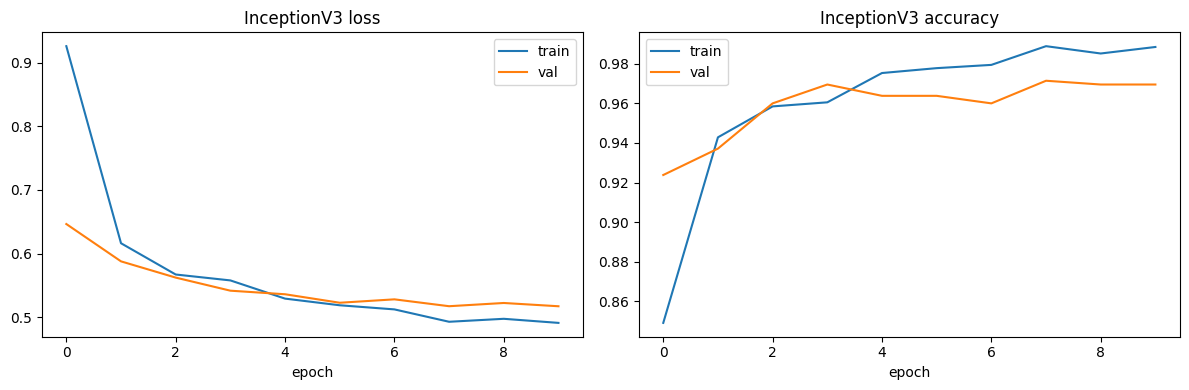

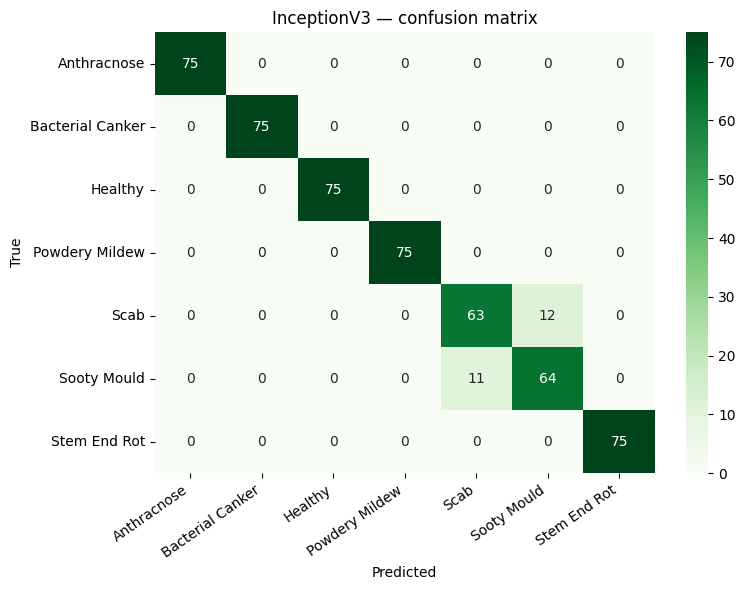

                  precision    recall  f1-score   support

     Anthracnose       1.00      1.00      1.00        75
Bacterial Canker       1.00      1.00      1.00        75
         Healthy       1.00      1.00      1.00        75
  Powdery Mildew       1.00      1.00      1.00        75
            Scab       0.85      0.84      0.85        75
     Sooty Mould       0.84      0.85      0.85        75
    Stem End Rot       1.00      1.00      1.00        75

        accuracy                           0.96       525
       macro avg       0.96      0.96      0.96       525
    weighted avg       0.96      0.96      0.96       525


TRAINING BASELINE: Xception
Downloading: "https://github.com/rwightman/pytorch-image-models/releases/download/v0.1-cadene/xception-43020ad28.pth" to /root/.cache/torch/hub/checkpoints/xception-43020ad28.pth
[model] using 'xception'
[Xception] ep 01/10 tr_loss 0.780 tr_acc 0.877 | va_loss 0.565 va_acc 0.943
[Xception] ep 02/10 tr_loss 0.562 tr_acc 0.959 | v

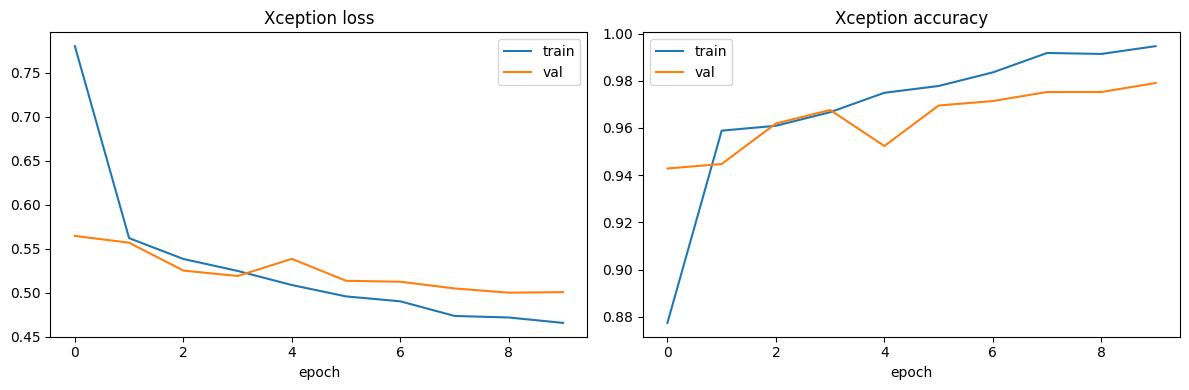

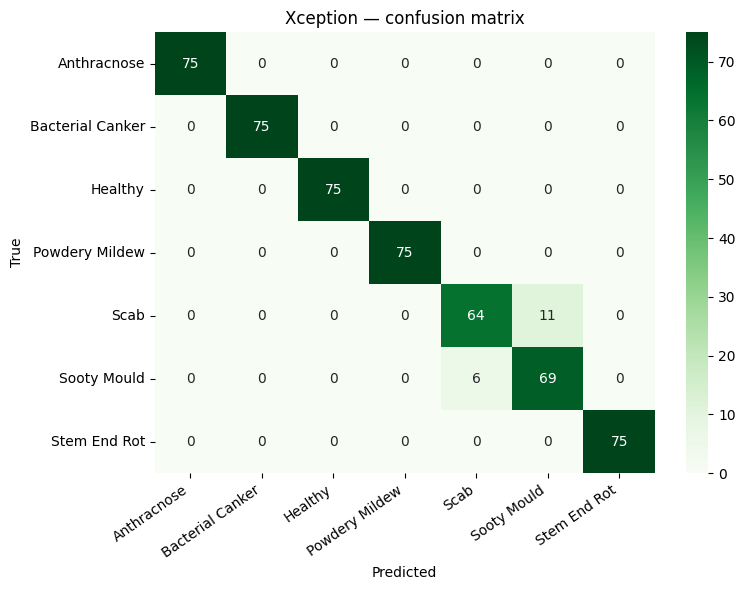

                  precision    recall  f1-score   support

     Anthracnose       1.00      1.00      1.00        75
Bacterial Canker       1.00      1.00      1.00        75
         Healthy       1.00      1.00      1.00        75
  Powdery Mildew       1.00      1.00      1.00        75
            Scab       0.91      0.85      0.88        75
     Sooty Mould       0.86      0.92      0.89        75
    Stem End Rot       1.00      1.00      1.00        75

        accuracy                           0.97       525
       macro avg       0.97      0.97      0.97       525
    weighted avg       0.97      0.97      0.97       525


TRAINING BASELINE: MobileNetV3


model.safetensors:   0%|          | 0.00/22.1M [00:00<?, ?B/s]

[model] using 'mobilenetv3_large_100'
[MobileNetV3] ep 01/10 tr_loss 1.140 tr_acc 0.801 | va_loss 0.926 va_acc 0.853
[MobileNetV3] ep 02/10 tr_loss 0.717 tr_acc 0.927 | va_loss 0.695 va_acc 0.939
[MobileNetV3] ep 03/10 tr_loss 0.627 tr_acc 0.956 | va_loss 0.688 va_acc 0.943
[MobileNetV3] ep 04/10 tr_loss 0.580 tr_acc 0.971 | va_loss 0.685 va_acc 0.937
[MobileNetV3] ep 05/10 tr_loss 0.562 tr_acc 0.972 | va_loss 0.645 va_acc 0.949
[MobileNetV3] ep 06/10 tr_loss 0.550 tr_acc 0.977 | va_loss 0.636 va_acc 0.954
[MobileNetV3] ep 07/10 tr_loss 0.534 tr_acc 0.981 | va_loss 0.605 va_acc 0.964
[MobileNetV3] ep 08/10 tr_loss 0.525 tr_acc 0.986 | va_loss 0.591 va_acc 0.964
[MobileNetV3] ep 09/10 tr_loss 0.524 tr_acc 0.988 | va_loss 0.587 va_acc 0.964
[MobileNetV3] ep 10/10 tr_loss 0.523 tr_acc 0.986 | va_loss 0.588 va_acc 0.964

MobileNetV3: test_acc=0.9619  f1=0.9619  gap=0.0286


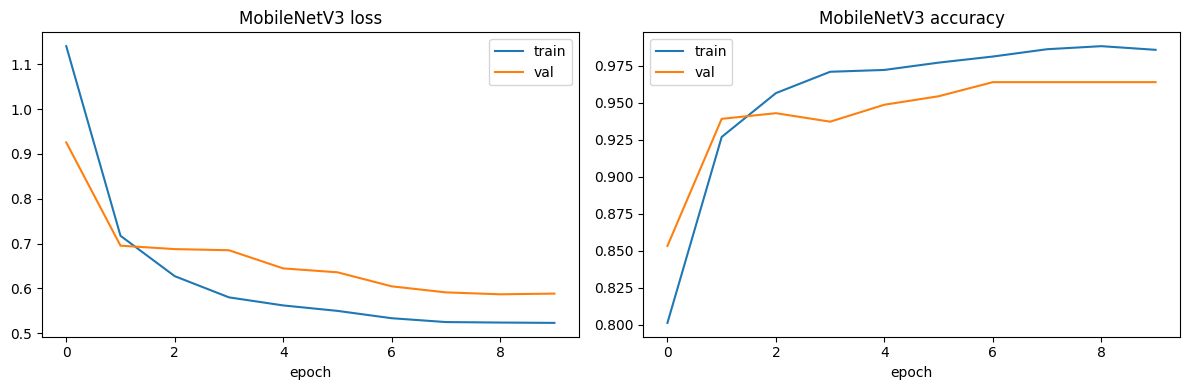

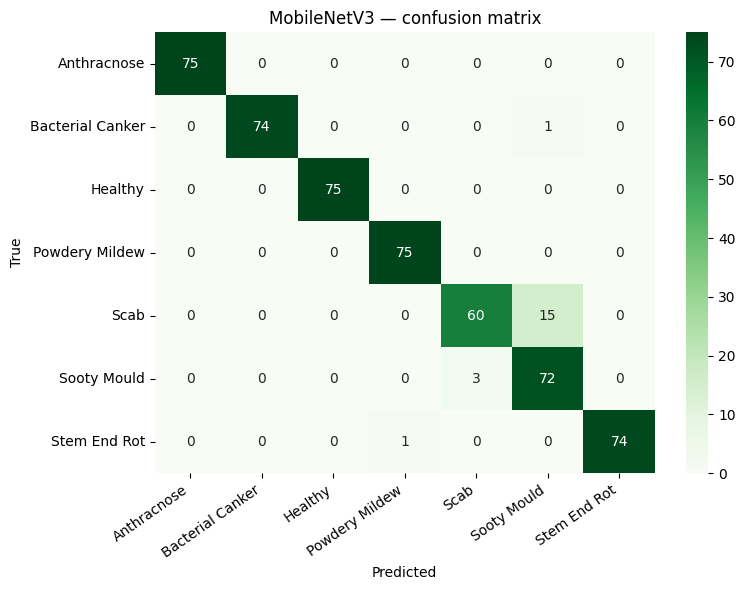

                  precision    recall  f1-score   support

     Anthracnose       1.00      1.00      1.00        75
Bacterial Canker       1.00      0.99      0.99        75
         Healthy       1.00      1.00      1.00        75
  Powdery Mildew       0.99      1.00      0.99        75
            Scab       0.95      0.80      0.87        75
     Sooty Mould       0.82      0.96      0.88        75
    Stem End Rot       1.00      0.99      0.99        75

        accuracy                           0.96       525
       macro avg       0.97      0.96      0.96       525
    weighted avg       0.97      0.96      0.96       525


TRAINING BASELINE: EfficientNet_B0
[model] using 'efficientnet_b0'
[EfficientNet_B0] ep 01/10 tr_loss 1.249 tr_acc 0.791 | va_loss 0.829 va_acc 0.899
[EfficientNet_B0] ep 02/10 tr_loss 0.730 tr_acc 0.919 | va_loss 0.722 va_acc 0.910
[EfficientNet_B0] ep 03/10 tr_loss 0.636 tr_acc 0.954 | va_loss 0.633 va_acc 0.956
[EfficientNet_B0] ep 04/10 tr_loss 0.591 t

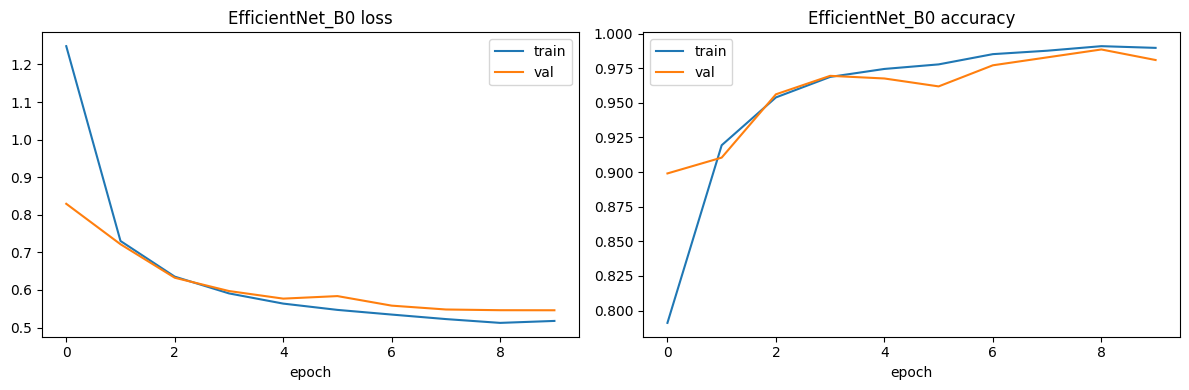

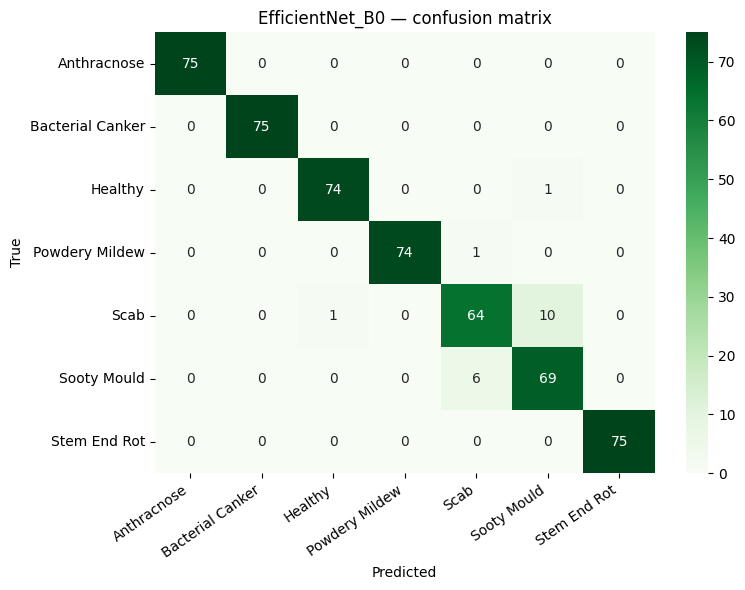

                  precision    recall  f1-score   support

     Anthracnose       1.00      1.00      1.00        75
Bacterial Canker       1.00      1.00      1.00        75
         Healthy       0.99      0.99      0.99        75
  Powdery Mildew       1.00      0.99      0.99        75
            Scab       0.90      0.85      0.88        75
     Sooty Mould       0.86      0.92      0.89        75
    Stem End Rot       1.00      1.00      1.00        75

        accuracy                           0.96       525
       macro avg       0.96      0.96      0.96       525
    weighted avg       0.96      0.96      0.96       525



,params_M,test_acc,precision,recall,f1,train_acc,overfit_gap,minutes
VGG16,134.29,0.956190,0.955994,0.956190,0.956046,0.978207,0.0220,46.3
InceptionV3,21.80,0.956190,0.956208,0.956190,0.956189,0.992188,0.0360,47.9
Xception,20.82,0.967619,0.968112,0.967619,0.967583,0.994243,0.0266,48.2
MobileNetV3,4.21,0.961905,0.965344,0.961905,0.961851,0.990543,0.0286,48.0
EfficientNet_B0,4.02,0.963810,0.964368,0.963810,0.963856,0.993832,0.0300,50.2


In [20]:
for name in BASELINES:
    print("\n" + "="*60)
    print("TRAINING BASELINE:", name)
    print("="*60)
    t0 = time.time()
    model = build_baseline(name)
    model, hist = train_model(model, train_loader, val_loader,
                              EPOCHS_BASELINE, BEST_PARAMS["lr"],
                              BEST_PARAMS["wd"], name)
    res = evaluate(model, test_loader)
    train_res = evaluate(model, train_loader)  # for the overfitting check

    RESULTS[name] = {
        "params_M": round(count_params(model), 2),
        "test_acc": res["acc"], "precision": res["precision"],
        "recall": res["recall"], "f1": res["f1"],
        "train_acc": train_res["acc"],
        "overfit_gap": round(train_res["acc"] - res["acc"], 4),
        "minutes": round((time.time()-t0)/60, 1),
    }
    TEST_PRED[name] = res["y_pred"]

    print(f"\n{name}: test_acc={res['acc']:.4f}  f1={res['f1']:.4f}  "
          f"gap={RESULTS[name]['overfit_gap']:.4f}")
    plot_history(hist, name)
    plot_cm(res["y_true"], res["y_pred"], name)
    print(classification_report(res["y_true"], res["y_pred"],
                                target_names=CLASSES, zero_division=0))
    torch.save(model.state_dict(), f"{RESULTS_DIR}/{name}.pt")
    del model; cleanup()

# keep the test ground-truth once for the statistical tests
Y_TEST = res["y_true"]
pd.DataFrame(RESULTS).T

## 9. Optuna hyper-parameters

A full Optuna search is very expensive, so we **reuse the manual best parameters**
shown earlier. A *small optional demo* study can be enabled with
`RUN_OPTUNA = True` in the config — it only runs a few short trials so you can
see the mechanism without the huge cost.

In [21]:
print("Best parameters in use (manual / from previous Optuna):")
for k, v in BEST_PARAMS.items():
    print(f"  {k:15s}: {v}")

if RUN_OPTUNA:
    import optuna
    def objective(trial):
        lr = trial.suggest_float("lr", 1e-5, 1e-3, log=True)
        wd = trial.suggest_float("wd", 1e-6, 1e-3, log=True)
        dp = trial.suggest_float("dropout", 0.1, 0.5)
        m  = AAENet(NUM_CLASSES, dropout=dp)
        m, _ = train_model(m, train_loader, val_loader,
                           OPTUNA_EPOCHS, lr, wd, "optuna",
                           patience=2, verbose=False)
        acc = evaluate(m, val_loader)["acc"]
        del m; cleanup()
        return acc
    study = optuna.create_study(direction="maximize")
    study.optimize(objective, n_trials=OPTUNA_TRIALS)
    print("Demo best:", study.best_params, "val_acc=", round(study.best_value, 4))
    with open(f"{RESULTS_DIR}/optuna_demo_best.json", "w") as fh:
        json.dump({"best_params": study.best_params,
                   "best_value": study.best_value}, fh, indent=2)
else:
    print("\nRUN_OPTUNA is False -> skipping the search (using BEST_PARAMS).")
    with open(f"{RESULTS_DIR}/best_params.json", "w") as fh:
        json.dump(BEST_PARAMS, fh, indent=2)

Best parameters in use (manual / from previous Optuna):
  lr             : 0.000249
  wd             : 7.97e-05
  dropout        : 0.276633
  lambda_supcon  : 0.212043

RUN_OPTUNA is False -> skipping the search (using BEST_PARAMS).


## 10. Proposed hybrid model (AA-ENet)
Trained with the manual best parameters.

TRAINING PROPOSED MODEL: AA-ENet
[AA-ENet] ep 01/15 tr_loss 0.862 tr_acc 0.817 | va_loss 0.572 va_acc 0.956
[AA-ENet] ep 02/15 tr_loss 0.557 tr_acc 0.954 | va_loss 0.552 va_acc 0.975
[AA-ENet] ep 03/15 tr_loss 0.544 tr_acc 0.962 | va_loss 0.573 va_acc 0.949
[AA-ENet] ep 04/15 tr_loss 0.528 tr_acc 0.963 | va_loss 0.547 va_acc 0.962
[AA-ENet] ep 05/15 tr_loss 0.517 tr_acc 0.969 | va_loss 0.534 va_acc 0.973
[AA-ENet] ep 06/15 tr_loss 0.509 tr_acc 0.975 | va_loss 0.531 va_acc 0.973
[AA-ENet] ep 07/15 tr_loss 0.488 tr_acc 0.986 | va_loss 0.548 va_acc 0.970
[AA-ENet] ep 08/15 tr_loss 0.484 tr_acc 0.990 | va_loss 0.539 va_acc 0.971
[AA-ENet] ep 09/15 tr_loss 0.477 tr_acc 0.993 | va_loss 0.518 va_acc 0.977
[AA-ENet] ep 10/15 tr_loss 0.483 tr_acc 0.988 | va_loss 0.517 va_acc 0.979
[AA-ENet] ep 11/15 tr_loss 0.478 tr_acc 0.992 | va_loss 0.524 va_acc 0.973
[AA-ENet] ep 12/15 tr_loss 0.472 tr_acc 0.993 | va_loss 0.513 va_acc 0.979
[AA-ENet] ep 13/15 tr_loss 0.474 tr_acc 0.992 | va_loss 0.524 va_ac

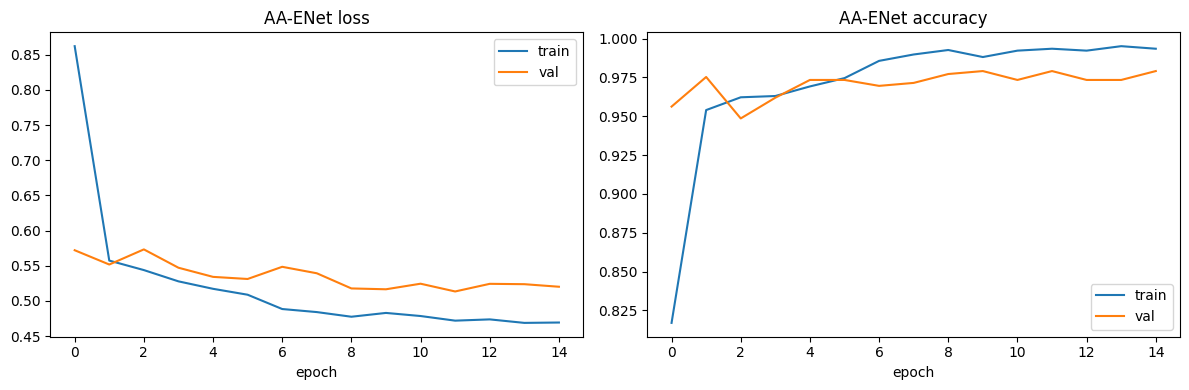

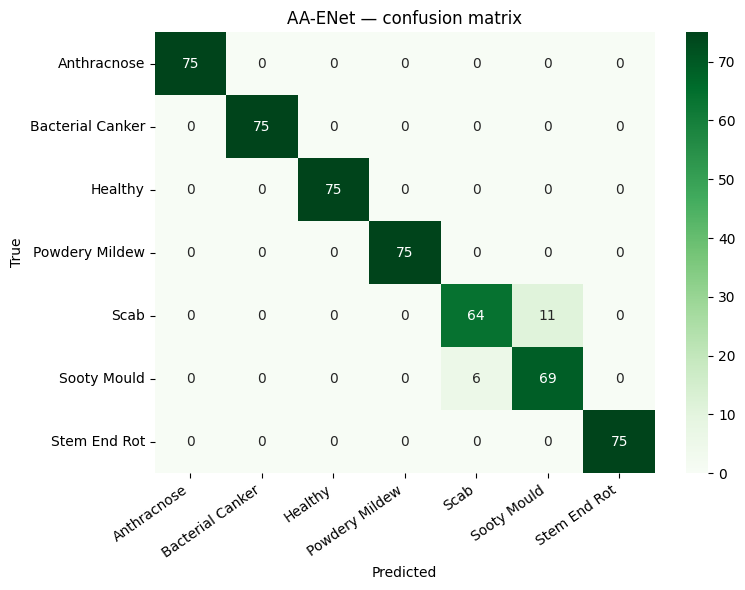

                  precision    recall  f1-score   support

     Anthracnose       1.00      1.00      1.00        75
Bacterial Canker       1.00      1.00      1.00        75
         Healthy       1.00      1.00      1.00        75
  Powdery Mildew       1.00      1.00      1.00        75
            Scab       0.91      0.85      0.88        75
     Sooty Mould       0.86      0.92      0.89        75
    Stem End Rot       1.00      1.00      1.00        75

        accuracy                           0.97       525
       macro avg       0.97      0.97      0.97       525
    weighted avg       0.97      0.97      0.97       525


Overfitting check: train-test accuracy gap = 0.0287  ->  OK (small gap)


In [22]:
print("="*60)
print("TRAINING PROPOSED MODEL: AA-ENet")
print("="*60)
t0 = time.time()
prop = AAENet(NUM_CLASSES, dropout=BEST_PARAMS["dropout"])
prop, hist = train_model(prop, train_loader, val_loader,
                         EPOCHS_PROPOSED, BEST_PARAMS["lr"],
                         BEST_PARAMS["wd"], "AA-ENet")
res  = evaluate(prop, test_loader)
trr  = evaluate(prop, train_loader)

RESULTS["AA-ENet (Proposed)"] = {
    "params_M": round(count_params(prop), 2),
    "test_acc": res["acc"], "precision": res["precision"],
    "recall": res["recall"], "f1": res["f1"],
    "train_acc": trr["acc"],
    "overfit_gap": round(trr["acc"] - res["acc"], 4),
    "minutes": round((time.time()-t0)/60, 1),
}
TEST_PRED["AA-ENet (Proposed)"] = res["y_pred"]

print(f"\nAA-ENet: test_acc={res['acc']:.4f}  f1={res['f1']:.4f}  "
      f"train_acc={trr['acc']:.4f}  gap={RESULTS['AA-ENet (Proposed)']['overfit_gap']:.4f}")
plot_history(hist, "AA-ENet")
plot_cm(res["y_true"], res["y_pred"], "AA-ENet")
print(classification_report(res["y_true"], res["y_pred"],
                            target_names=CLASSES, zero_division=0))
torch.save(prop.state_dict(), f"{RESULTS_DIR}/AA-ENet_proposed.pt")

gap = RESULTS["AA-ENet (Proposed)"]["overfit_gap"]
print("\nOverfitting check: train-test accuracy gap = "
      f"{gap:.4f}  ->  "
      f"{'OK (small gap)' if gap < 0.05 else 'watch the gap'}")
del prop; cleanup()

## 11. 5-Fold cross-validation
Proposed model **and** the strongest baseline (EfficientNet-B0) are run on the *same* folds, so a paired statistical test is valid later.

In [23]:
skf = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=SEED)
X = df.reset_index(drop=True)
y = X["label"].values

cv_prop, cv_base = [], []
for fold, (tr_idx, te_idx) in enumerate(skf.split(X, y), 1):
    print(f"\n----- Fold {fold}/{CV_FOLDS} -----")
    fold_tr = X.iloc[tr_idx]
    # inner split for validation / early stopping
    f_tr, f_va = train_test_split(fold_tr, test_size=0.15,
                                  stratify=fold_tr["label"],
                                  random_state=SEED)
    f_te = X.iloc[te_idx]
    tl, vl, te = make_loaders(f_tr, f_va, f_te)

    m1 = AAENet(NUM_CLASSES, dropout=BEST_PARAMS["dropout"])
    m1, _ = train_model(m1, tl, vl, EPOCHS_CV, BEST_PARAMS["lr"],
                        BEST_PARAMS["wd"], f"AA-ENet f{fold}",
                        patience=3, verbose=False)
    a1 = evaluate(m1, te)["acc"]; del m1; cleanup()

    m2 = build_baseline("EfficientNet_B0")
    m2, _ = train_model(m2, tl, vl, EPOCHS_CV, BEST_PARAMS["lr"],
                        BEST_PARAMS["wd"], f"EffB0 f{fold}",
                        patience=3, verbose=False)
    a2 = evaluate(m2, te)["acc"]; del m2; cleanup()

    cv_prop.append(a1); cv_base.append(a2)
    print(f"Fold {fold}: AA-ENet={a1:.4f}  EfficientNet_B0={a2:.4f}")

cv_df = pd.DataFrame({"fold": list(range(1, CV_FOLDS+1)),
                      "AA-ENet": cv_prop, "EfficientNet_B0": cv_base})
cv_df.to_csv(f"{RESULTS_DIR}/cv_results.csv", index=False)
print("\n", cv_df)
print(f"\nAA-ENet  CV acc: {np.mean(cv_prop):.4f} +/- {np.std(cv_prop):.4f}")
print(f"EffNetB0 CV acc: {np.mean(cv_base):.4f} +/- {np.std(cv_base):.4f}")


----- Fold 1/5 -----
[model] using 'efficientnet_b0'
Fold 1: AA-ENet=0.9643  EfficientNet_B0=0.9700

----- Fold 2/5 -----
[model] using 'efficientnet_b0'
Fold 2: AA-ENet=0.9729  EfficientNet_B0=0.9686

----- Fold 3/5 -----
[model] using 'efficientnet_b0'
Fold 3: AA-ENet=0.9714  EfficientNet_B0=0.9743

----- Fold 4/5 -----
[model] using 'efficientnet_b0'
Fold 4: AA-ENet=0.9671  EfficientNet_B0=0.9614

----- Fold 5/5 -----
[model] using 'efficientnet_b0'
Fold 5: AA-ENet=0.9557  EfficientNet_B0=0.9557

    fold   AA-ENet  EfficientNet_B0
0     1  0.964286         0.970000
1     2  0.972857         0.968571
2     3  0.971429         0.974286
3     4  0.967143         0.961429
4     5  0.955714         0.955714

AA-ENet  CV acc: 0.9663 +/- 0.0061
EffNetB0 CV acc: 0.9660 +/- 0.0066


## 12. Ablation study

We remove components of the proposed model to see how each contributes:
- **Backbone only** (EfficientNet-B0 features → linear head)
- **+ CBAM**
- **+ Transformer**
- **Full AA-ENet** (CBAM + Transformer)
- **Full, no augmentation** (shows the value of the augmentation policy)

In [ ]:
ablation = []

configs = [
    ("Backbone only",     dict(use_cbam=False, use_transformer=False), True),
    ("+ CBAM",            dict(use_cbam=True,  use_transformer=False), True),
    ("+ Transformer",     dict(use_cbam=False, use_transformer=True),  True),
    ("Full AA-ENet",      dict(use_cbam=True,  use_transformer=True),  True),
    ("Full, no aug",      dict(use_cbam=True,  use_transformer=True),  False),
]

for label, kw, use_aug in configs:
    tl, vl, te = make_loaders(train_df, val_df, test_df, train_aug=use_aug)
    m = AAENet(NUM_CLASSES, dropout=BEST_PARAMS["dropout"], **kw)
    m, _ = train_model(m, tl, vl, EPOCHS_ABLATION, BEST_PARAMS["lr"],
                       BEST_PARAMS["wd"], label, patience=3, verbose=False)
    r = evaluate(m, te)
    ablation.append({"config": label, "test_acc": round(r["acc"], 4),
                     "f1": round(r["f1"], 4),
                     "params_M": round(count_params(m), 2)})
    print(f"{label:18s}: acc={r['acc']:.4f}  f1={r['f1']:.4f}")
    del m; cleanup()

abl_df = pd.DataFrame(ablation)
abl_df.to_csv(f"{RESULTS_DIR}/ablation.csv", index=False)

plt.figure(figsize=(9, 4))
sns.barplot(data=abl_df, x="config", y="test_acc", color="#3C7A5A")
plt.title("Ablation study"); plt.ylabel("Test accuracy")
plt.ylim(0, 1); plt.xticks(rotation=20, ha="right"); plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/ablation.png", dpi=130)
plt.show()
abl_df

## 13. Statistical significance tests

- **McNemar's test** on the hold-out test set: proposed vs. best baseline (compares disagreements on the same samples).
- **Paired t-test** on the 5 cross-validation fold accuracies (same folds for both models).

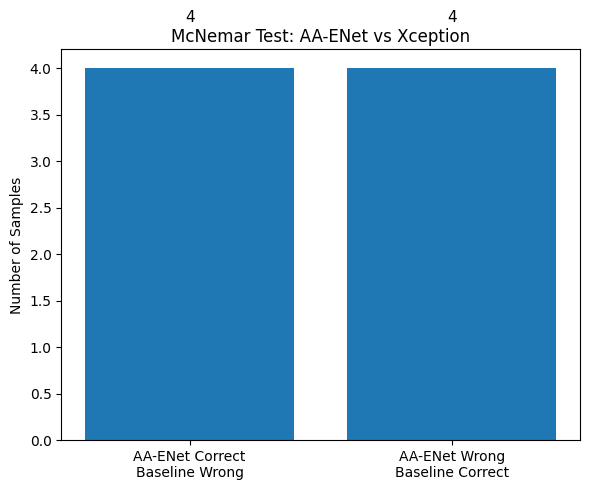

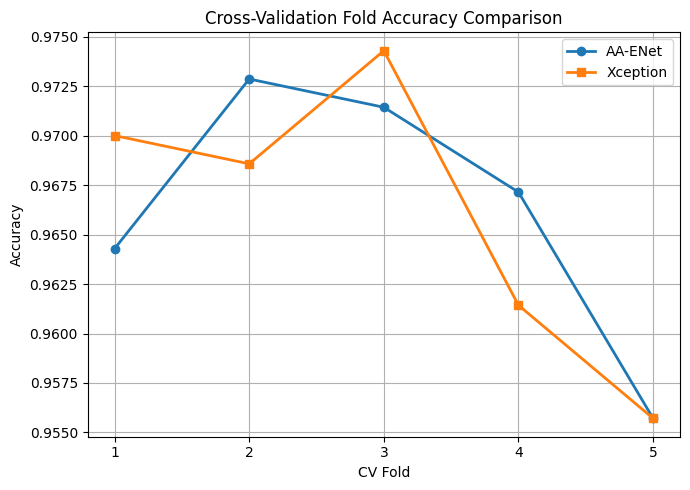

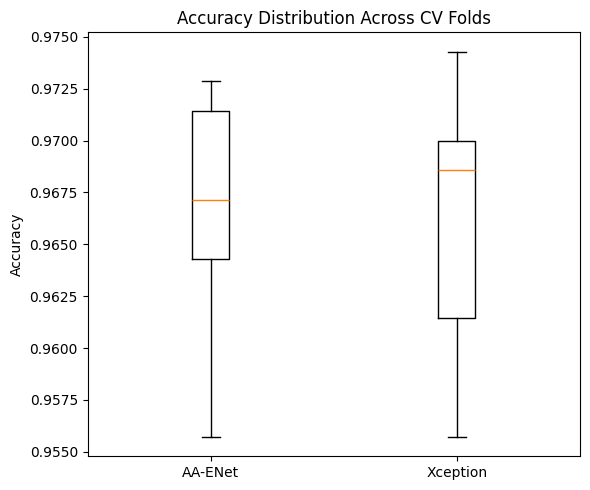

Figures successfully saved to:
/kaggle/working/results/


In [28]:
# ============================================================
# SAVE FIGURES TO KAGGLE DIRECTORY
# ============================================================

import os
import matplotlib.pyplot as plt
import numpy as np

# Fixed Kaggle save directory
FIG_DIR = "/kaggle/working/results"

os.makedirs(FIG_DIR, exist_ok=True)

# ------------------------------------------------------------
# 1. McNemar Test Figure
# ------------------------------------------------------------

plt.figure(figsize=(6,5))

labels = ['AA-ENet Correct\nBaseline Wrong',
          'AA-ENet Wrong\nBaseline Correct']
values = [n01, n10]

bars = plt.bar(labels, values)

plt.ylabel("Number of Samples")
plt.title(f"McNemar Test: AA-ENet vs {best_base}")

for bar in bars:
    h = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2,
             h + 0.5,
             f'{int(h)}',
             ha='center',
             fontsize=11)

plt.tight_layout()

plt.savefig("/kaggle/working/results/mcnemar_test.png",
            dpi=300,
            bbox_inches='tight')

plt.show()


# ------------------------------------------------------------
# 2. CV Fold Comparison Figure
# ------------------------------------------------------------

folds = np.arange(1, len(cv_prop)+1)

plt.figure(figsize=(7,5))

plt.plot(folds, cv_prop,
         marker='o',
         linewidth=2,
         label='AA-ENet')

plt.plot(folds, cv_base,
         marker='s',
         linewidth=2,
         label=best_base)

plt.xlabel("CV Fold")
plt.ylabel("Accuracy")
plt.title("Cross-Validation Fold Accuracy Comparison")

plt.xticks(folds)
plt.legend()
plt.grid(True)

plt.tight_layout()

plt.savefig("/kaggle/working/results/cv_fold_comparison.png",
            dpi=300,
            bbox_inches='tight')

plt.show()


# ------------------------------------------------------------
# 3. Boxplot Figure
# ------------------------------------------------------------

plt.figure(figsize=(6,5))

plt.boxplot([cv_prop, cv_base],
            labels=['AA-ENet', best_base])

plt.ylabel("Accuracy")
plt.title("Accuracy Distribution Across CV Folds")

plt.tight_layout()

plt.savefig("/kaggle/working/results/cv_accuracy_boxplot.png",
            dpi=300,
            bbox_inches='tight')

plt.show()


# ------------------------------------------------------------
# Saved confirmation
# ------------------------------------------------------------

print("Figures successfully saved to:")
print("/kaggle/working/results/")

In [25]:
# ---- McNemar's test on the test set ----
best_base = max(
    [k for k in RESULTS if k != "AA-ENet (Proposed)"],
    key=lambda k: RESULTS[k]["test_acc"])
print("Best baseline:", best_base)

a = TEST_PRED["AA-ENet (Proposed)"] == Y_TEST   # proposed correct?
b = TEST_PRED[best_base] == Y_TEST              # baseline correct?
n01 = int(np.sum(a & ~b))   # proposed right, baseline wrong
n10 = int(np.sum(~a & b))   # proposed wrong, baseline right

if (n01 + n10) == 0:
    mc_stat, mc_p = 0.0, 1.0
else:
    mc_stat = (abs(n01 - n10) - 1)**2 / (n01 + n10)   # with continuity corr.
    mc_p = float(stats.chi2.sf(mc_stat, df=1))

print(f"McNemar: n01={n01}, n10={n10}, chi2={mc_stat:.4f}, p={mc_p:.4f}")
print("=> statistically significant (p<0.05)" if mc_p < 0.05
      else "=> no significant difference (p>=0.05)")

# ---- Paired t-test across CV folds ----
t_stat, t_p = stats.ttest_rel(cv_prop, cv_base)
print(f"\nPaired t-test (CV folds): t={t_stat:.4f}, p={t_p:.4f}")
print("=> significant (p<0.05)" if t_p < 0.05 else "=> not significant (p>=0.05)")

with open(f"{RESULTS_DIR}/statistical_tests.json", "w") as fh:
    json.dump({"mcnemar": {"n01": n01, "n10": n10,
                           "chi2": mc_stat, "p": mc_p,
                           "vs": best_base},
               "paired_ttest": {"t": float(t_stat), "p": float(t_p)}},
              fh, indent=2)

Best baseline: Xception
McNemar: n01=4, n10=4, chi2=0.1250, p=0.7237
=> no significant difference (p>=0.05)

Paired t-test (CV folds): t=0.1336, p=0.9001
=> not significant (p>=0.05)


## 14. Benchmarking comparison

                    params_M  test_acc  precision  recall      f1  train_acc  \
AA-ENet (Proposed)      4.57    0.9676     0.9681  0.9676  0.9676     0.9963   
Xception               20.82    0.9676     0.9681  0.9676  0.9676     0.9942   
EfficientNet_B0         4.02    0.9638     0.9644  0.9638  0.9639     0.9938   
MobileNetV3             4.21    0.9619     0.9653  0.9619  0.9619     0.9905   
InceptionV3            21.80    0.9562     0.9562  0.9562  0.9562     0.9922   
VGG16                 134.29    0.9562     0.9560  0.9562  0.9560     0.9782   

                    overfit_gap  minutes  
AA-ENet (Proposed)       0.0287     68.8  
Xception                 0.0266     48.2  
EfficientNet_B0          0.0300     50.2  
MobileNetV3              0.0286     48.0  
InceptionV3              0.0360     47.9  
VGG16                    0.0220     46.3  


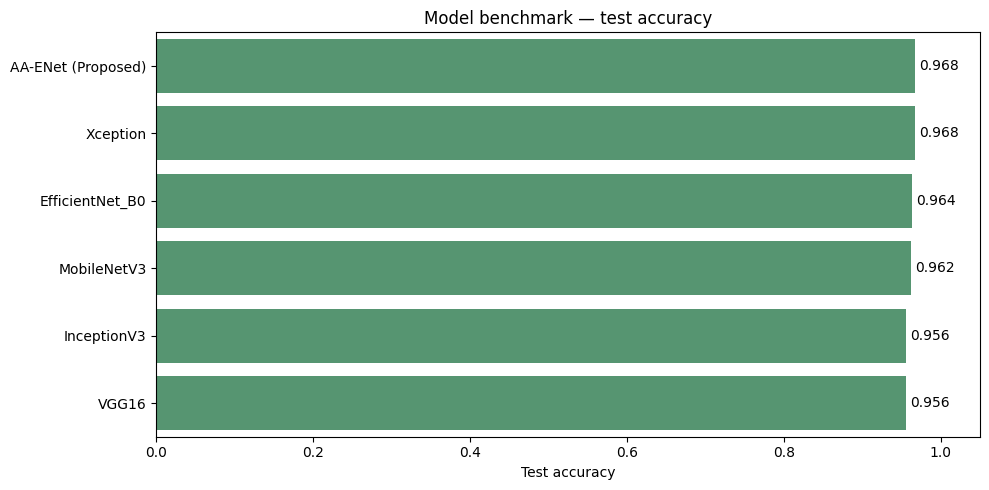

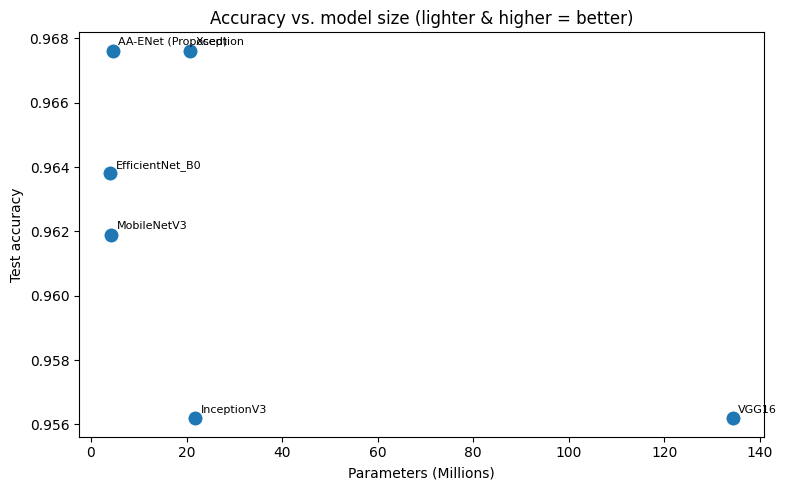

In [29]:
bench = pd.DataFrame(RESULTS).T
bench = bench[["params_M", "test_acc", "precision", "recall",
               "f1", "train_acc", "overfit_gap", "minutes"]]
bench = bench.sort_values("test_acc", ascending=False)
bench.to_csv(f"{RESULTS_DIR}/benchmark_comparison.csv")
print(bench.round(4))

order = bench.index.tolist()
plt.figure(figsize=(10, 5))
sns.barplot(x=bench["test_acc"].values, y=order, color="#4C9F70")
for i, v in enumerate(bench["test_acc"].values):
    plt.text(v + 0.005, i, f"{v:.3f}", va="center")
plt.xlim(0, 1.05); plt.xlabel("Test accuracy")
plt.title("Model benchmark — test accuracy")
plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/benchmark_accuracy.png", dpi=130)
plt.show()

plt.figure(figsize=(8, 5))
sns.scatterplot(x=bench["params_M"], y=bench["test_acc"], s=120)
for n in bench.index:
    plt.annotate(n, (bench.loc[n, "params_M"], bench.loc[n, "test_acc"]),
                 fontsize=8, xytext=(4, 4), textcoords="offset points")
plt.xlabel("Parameters (Millions)"); plt.ylabel("Test accuracy")
plt.title("Accuracy vs. model size (lighter & higher = better)")
plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/accuracy_vs_size.png", dpi=130)
plt.show()

## 15. Explainable AI

- **Grad-CAM** — where the proposed model looks.
- **LIME** — superpixels supporting the prediction.
- **SHAP** — pixel-level contribution (GradientExplainer).

We reload the saved proposed model and explain a few test images.

In [30]:
# Reload the trained proposed model
xai_model = AAENet(NUM_CLASSES, dropout=BEST_PARAMS["dropout"]).to(DEVICE)
xai_model.load_state_dict(torch.load(f"{RESULTS_DIR}/AA-ENet_proposed.pt",
                                     map_location=DEVICE))
xai_model.eval()

# pick a few test images (one per class where possible)
xai_rows = (test_df.groupby("class", group_keys=False)
                   .head(1).reset_index(drop=True))
xai_rows = xai_rows.head(6)
print("Explaining", len(xai_rows), "images")

Explaining 6 images


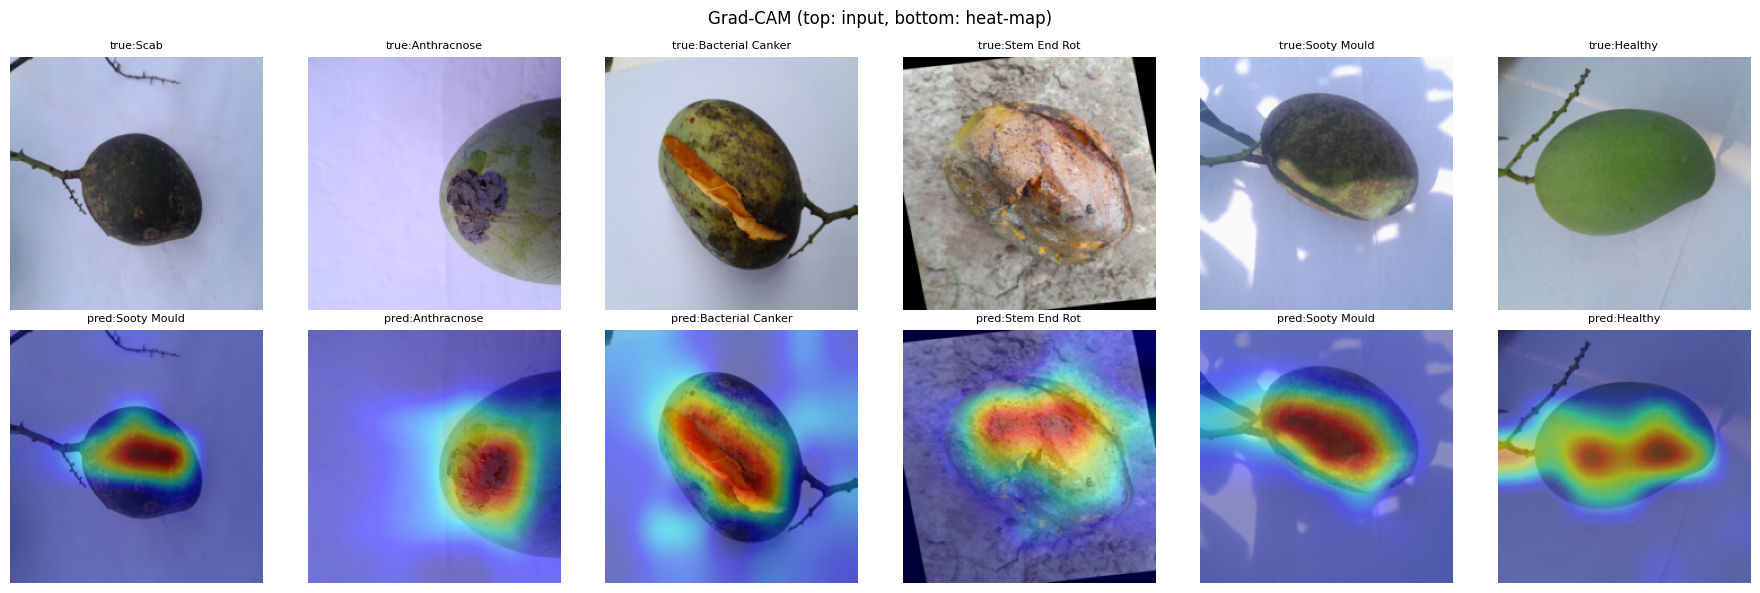

In [31]:
# ---------------- Grad-CAM ----------------
class GradCAM:
    def __init__(self, model, target):
        self.model = model
        self.act = None
        target.register_forward_hook(self._hook)
    def _hook(self, m, i, o):
        self.act = o
    def __call__(self, x, cls=None):
        self.model.zero_grad()
        out = self.model(x)
        if cls is None:
            cls = out.argmax(1)
        score = out.gather(1, cls.view(-1, 1)).sum()
        grads = torch.autograd.grad(score, self.act)[0]
        w = grads.mean(dim=(2, 3), keepdim=True)
        cam = F.relu((w * self.act).sum(1))
        cam = cam / (cam.amax(dim=(1, 2), keepdim=True) + 1e-8)
        return cam.detach().cpu().numpy(), out.argmax(1).cpu().numpy()

cam_engine = GradCAM(xai_model, xai_model.reduce)  # hook the reduced conv map

fig, axes = plt.subplots(2, len(xai_rows), figsize=(3*len(xai_rows), 6))
for j, (_, row) in enumerate(xai_rows.iterrows()):
    img = Image.open(row["path"]).convert("RGB")
    x = eval_tf(img).unsqueeze(0).to(DEVICE)
    cam, pred = cam_engine(x)
    cam = cam[0]
    cam_rs = np.array(Image.fromarray((cam*255).astype(np.uint8))
                      .resize((IMG_SIZE, IMG_SIZE))) / 255.0
    base = denorm(eval_tf(img)).permute(1, 2, 0).numpy()
    axes[0, j].imshow(base); axes[0, j].axis("off")
    axes[0, j].set_title(f"true:{row['class']}", fontsize=8)
    axes[1, j].imshow(base); axes[1, j].imshow(cam_rs, cmap="jet", alpha=0.45)
    axes[1, j].axis("off")
    axes[1, j].set_title(f"pred:{CLASSES[pred[0]]}", fontsize=8)
plt.suptitle("Grad-CAM (top: input, bottom: heat-map)")
plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/gradcam.png", dpi=130)
plt.show()

  0%|          | 0/200 [00:00<?, ?it/s]

  0%|          | 0/200 [00:00<?, ?it/s]

  0%|          | 0/200 [00:00<?, ?it/s]

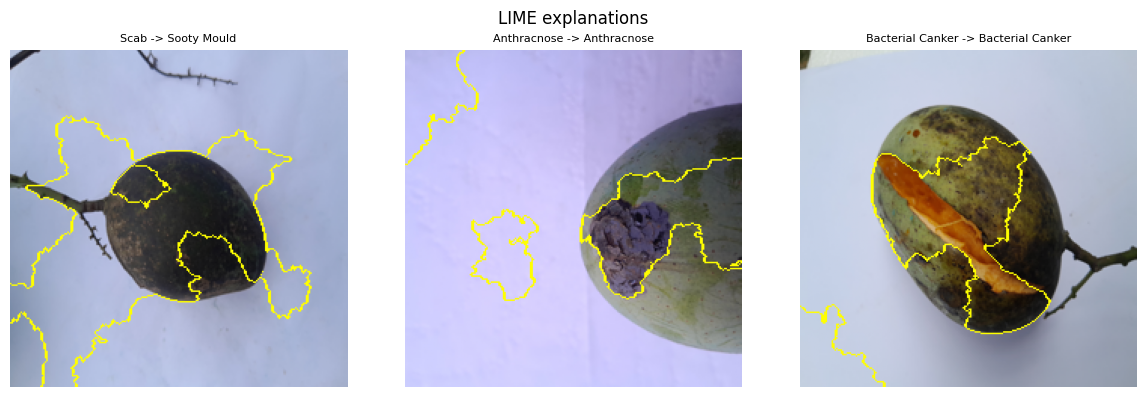

In [32]:
# ---------------- LIME ----------------
try:
    from lime import lime_image
    from skimage.segmentation import mark_boundaries

    def lime_predict(images):
        xs = torch.stack([
            eval_tf(Image.fromarray(im.astype(np.uint8))) for im in images
        ]).to(DEVICE)
        with torch.no_grad():
            logits = xai_model(xs)
            return F.softmax(logits, dim=1).cpu().numpy()

    explainer = lime_image.LimeImageExplainer()
    n = min(3, len(xai_rows))
    fig, axes = plt.subplots(1, n, figsize=(4*n, 4))
    axes = np.atleast_1d(axes)
    for j in range(n):
        row = xai_rows.iloc[j]
        arr = np.array(Image.open(row["path"]).convert("RGB")
                       .resize((IMG_SIZE, IMG_SIZE)))
        exp = explainer.explain_instance(arr, lime_predict,
                                         top_labels=1, hide_color=0,
                                         num_samples=200)
        lbl = exp.top_labels[0]
        temp, mask = exp.get_image_and_mask(lbl, positive_only=True,
                                            num_features=6, hide_rest=False)
        axes[j].imshow(mark_boundaries(temp/255.0, mask))
        axes[j].set_title(f"{row['class']} -> {CLASSES[lbl]}", fontsize=8)
        axes[j].axis("off")
    plt.suptitle("LIME explanations")
    plt.tight_layout()
    plt.savefig(f"{RESULTS_DIR}/lime.png", dpi=130)
    plt.show()
except Exception as e:
    print("LIME skipped:", e)

In [33]:
# ---------------- SHAP ----------------
try:
    import shap
    bg_rows = train_df.sample(8, random_state=SEED)
    bg = torch.stack([eval_tf(Image.open(p).convert("RGB"))
                      for p in bg_rows["path"]]).to(DEVICE)
    sm = torch.stack([eval_tf(Image.open(p).convert("RGB"))
                      for p in xai_rows["path"].head(2)]).to(DEVICE)

    explainer = shap.GradientExplainer(xai_model, bg)
    sv = explainer.shap_values(sm)

    sv_list = sv if isinstance(sv, list) else [sv]
    sv_np = [np.transpose(s, (0, 2, 3, 1)) for s in sv_list]
    sm_np = np.transpose(denorm(sm.cpu()).numpy(), (0, 2, 3, 1))
    shap.image_plot(sv_np, sm_np, show=False)
    plt.savefig(f"{RESULTS_DIR}/shap.png", dpi=130, bbox_inches="tight")
    plt.show()
    print("SHAP figure saved.")
except Exception as e:
    print("SHAP skipped:", e)

del xai_model; cleanup()

SHAP skipped: axes don't match array


## 16. Final results summary

In [34]:
print("="*64)
print(" FINAL RESULTS SUMMARY ".center(64, "="))
print("="*64)

summary = pd.DataFrame(RESULTS).T[
    ["params_M", "test_acc", "f1", "train_acc", "overfit_gap", "minutes"]
].sort_values("test_acc", ascending=False)
print(summary.round(4).to_string())

best_name = summary.index[0]
best_acc  = summary.loc[best_name, "test_acc"]
prop_acc  = RESULTS["AA-ENet (Proposed)"]["test_acc"]
prop_gap  = RESULTS["AA-ENet (Proposed)"]["overfit_gap"]

print("\n" + "-"*64)
print(f"Best model            : {best_name}  (acc={best_acc:.4f})")
print(f"Proposed AA-ENet      : acc={prop_acc:.4f}  "
      f"params={RESULTS['AA-ENet (Proposed)']['params_M']} M")
print(f"Overfitting gap       : {prop_gap:.4f}  "
      f"({'good, < 0.05' if prop_gap < 0.05 else 'monitor'})")
print(f"CV (AA-ENet)          : {np.mean(cv_prop):.4f} +/- {np.std(cv_prop):.4f}")
print(f"McNemar vs {best_base:15s}: p={mc_p:.4f}")
print(f"Paired t-test (CV)    : p={t_p:.4f}")
if 0.95 <= prop_acc <= 0.99 and prop_gap < 0.05:
    print("\nTarget reached: 95-98% accuracy with no significant overfitting.")
else:
    print("\nTip: if the target is not met, train a few more epochs or set "
          "MAX_PER_CLASS=None and FAST_MODE=False.")

summary.to_csv(f"{RESULTS_DIR}/final_summary.csv")

print("\nSaved artifacts in", RESULTS_DIR + ":")
for f in sorted(os.listdir(RESULTS_DIR)):
    print("  -", f)
print("\nDone.")

==================== FINAL RESULTS SUMMARY =====================
                    params_M  test_acc      f1  train_acc  overfit_gap  minutes
AA-ENet (Proposed)      4.57    0.9676  0.9676     0.9963       0.0287     68.8
Xception               20.82    0.9676  0.9676     0.9942       0.0266     48.2
EfficientNet_B0         4.02    0.9638  0.9639     0.9938       0.0300     50.2
MobileNetV3             4.21    0.9619  0.9619     0.9905       0.0286     48.0
InceptionV3            21.80    0.9562  0.9562     0.9922       0.0360     47.9
VGG16                 134.29    0.9562  0.9560     0.9782       0.0220     46.3

----------------------------------------------------------------
Best model            : AA-ENet (Proposed)  (acc=0.9676)
Proposed AA-ENet      : acc=0.9676  params=4.57 M
Overfitting gap       : 0.0287  (good, < 0.05)
CV (AA-ENet)          : 0.9663 +/- 0.0061
McNemar vs Xception       : p=0.7237
Paired t-test (CV)    : p=0.9001

Target reached: 95-98% accuracy with no si